In [7]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT.EnableImplicitMT(10)

Imos representar as eficiencias obtidas para cada sistema de colisión en función do número de nucleóns. Para iso, primeiro precisamos calcular a eficiencia da longtrack como $\varepsilon_{SciFi}\cdot\varepsilon_{VELO}$. A súa incerteza será calculada por ipropagación de incertezas.

In [8]:
scifi_oo = np.array([0.9518,0.0215])
velo_oo = np.array([0.9903,0.0043])
aux_oo= scifi_oo[0] * velo_oo[0]
erro_long = aux_oo * np.sqrt( (scifi_oo[1]/scifi_oo[0])**2 + (velo_oo[1]/velo_oo[0])**2 )
long_oo = np.array([aux_oo, erro_long])

#######################################

scifi_po = np.array([0.9599,0.0080])
velo_po = np.array([0.9939,0.0014])
aux_po= scifi_po[0] * velo_po[0]
erro_long_po = aux_po * np.sqrt( (scifi_po[1]/scifi_po[0])**2 + (velo_po[1]/velo_po[0])**2 )
long_po = np.array([aux_po, erro_long_po])


##################################

scifi_nene = np.array([0.9830,0.0685])
velo_nene = np.array([0.9990,0.0129])
aux_nene= scifi_nene[0] * velo_nene[0]
erro_long_nene = aux_nene * np.sqrt( (scifi_nene[1]/scifi_nene[0])**2 + (velo_nene[1]/velo_nene[0])**2 )
long_nene = np.array([aux_nene, erro_long_nene])



Ploteamos e imprimimos entón as eficiencias

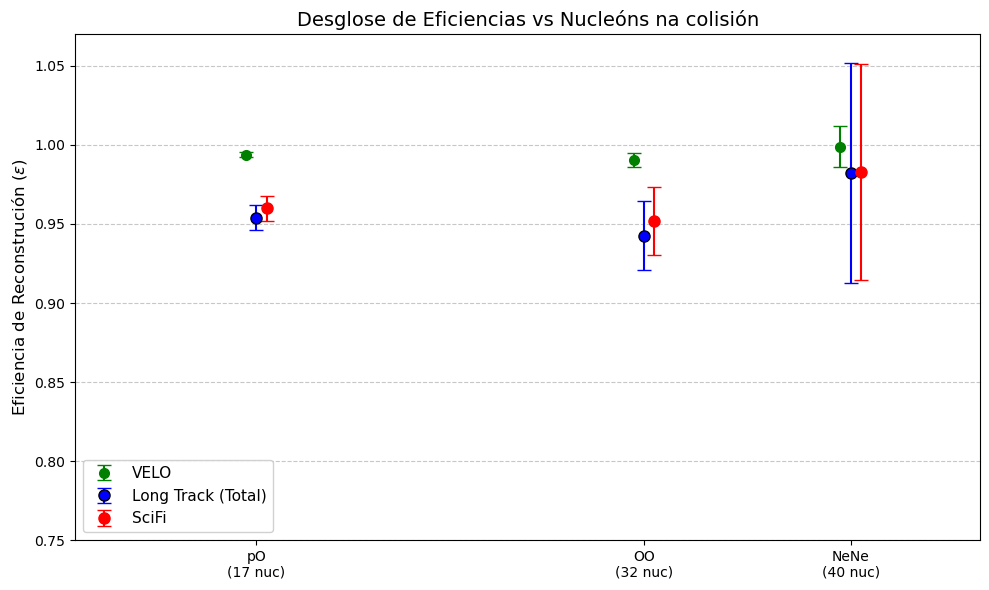

In [9]:
x_nucleons = np.array([17, 32, 40])
labels = ['pO', 'OO', 'NeNe']

# Agrupamos as Y e os erros por detector
y_velo   = [velo_po[0], velo_oo[0], velo_nene[0]]
err_velo = [velo_po[1], velo_oo[1], velo_nene[1]]

y_scifi   = [scifi_po[0], scifi_oo[0], scifi_nene[0]]
err_scifi = [scifi_po[1], scifi_oo[1], scifi_nene[1]]

y_long   = [long_po[0], long_oo[0], long_nene[0]]
err_long = [long_po[1], long_oo[1], long_nene[1]]


# CREACIÓN DA GRÁFICA

plt.figure(figsize=(10, 6))

# Desprazamento (offset) para que as barras non se tapen entre si
offset = 0.4

# Plot VELO 
plt.errorbar(x_nucleons - offset, y_velo, yerr=err_velo, 
             fmt='o', color='green', label='VELO', capsize=5, markersize=7)

# Plot Long Track 
plt.errorbar(x_nucleons, y_long, yerr=err_long, 
             fmt='o', color='blue', label='Long Track (Total)', capsize=5, markersize=8, markeredgecolor='black')

# Plot SciFi 
plt.errorbar(x_nucleons + offset, y_scifi, yerr=err_scifi, 
             fmt='o', color='red', label='SciFi', capsize=5, markersize=8)

# Detalles estéticos da gráfica
# Cambiamos os números do eixo X polas etiquetas con salto de liña
plt.xticks(x_nucleons, [f'{l}\n({x} nuc)' for l, x in zip(labels, x_nucleons)])


plt.ylabel('Eficiencia de Reconstrución ($\epsilon$)', fontsize=12)
plt.title('Desglose de Eficiencias vs Nucleóns na colisión', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=11, framealpha=0.9) # Lenda visible

# Axuste de límites 
plt.ylim(0.75, 1.07) 
plt.xlim(10, 45)

plt.tight_layout()
plt.show()

In [10]:
print("="*45)
print("     RESUMO DE EFICIENCIAS POR SISTEMA")
print("="*45)

# pO
print("\n▶ Eficiencias para pO:")
print("-" * 40)
print(f"  VELO      : {velo_po[0]*100:5.2f} %  ±  {velo_po[1]*100:4.2f} %")
print(f"  SciFi     : {scifi_po[0]*100:5.2f} %  ±  {scifi_po[1]*100:4.2f} %")
print(f"  LongTrack : {long_po[0]*100:5.2f} %  ±  {long_po[1]*100:4.2f} %")

# OO
print("\n\n▶ Eficiencias para OO:")
print("-" * 40)
print(f"  VELO      : {velo_oo[0]*100:5.2f} %  ±  {velo_oo[1]*100:4.2f} %")
print(f"  SciFi     : {scifi_oo[0]*100:5.2f} %  ±  {scifi_oo[1]*100:4.2f} %")
print(f"  LongTrack : {long_oo[0]*100:5.2f} %  ±  {long_oo[1]*100:4.2f} %")

# NeNe
print("\n\n▶ Eficiencias para NeNe:")
print("-" * 40)
print(f"  VELO      : {velo_nene[0]*100:5.2f} %  ±  {velo_nene[1]*100:4.2f} %")
print(f"  SciFi     : {scifi_nene[0]*100:5.2f} %  ±  {scifi_nene[1]*100:4.2f} %")
print(f"  LongTrack : {long_nene[0]*100:5.2f} %  ±  {long_nene[1]*100:4.2f} %")

print("\n" + "="*45)

     RESUMO DE EFICIENCIAS POR SISTEMA

▶ Eficiencias para pO:
----------------------------------------
  VELO      : 99.39 %  ±  0.14 %
  SciFi     : 95.99 %  ±  0.80 %
  LongTrack : 95.40 %  ±  0.81 %


▶ Eficiencias para OO:
----------------------------------------
  VELO      : 99.03 %  ±  0.43 %
  SciFi     : 95.18 %  ±  2.15 %
  LongTrack : 94.26 %  ±  2.17 %


▶ Eficiencias para NeNe:
----------------------------------------
  VELO      : 99.90 %  ±  1.29 %
  SciFi     : 98.30 %  ±  6.85 %
  LongTrack : 98.20 %  ±  6.96 %

